In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, requests

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

In [2]:
df = pd.read_csv('chemicals_in_wind_tunnel.csv', index_col=0)
print(df.shape)
df.head()
df.min(numeric_only=True).min()


(17921, 289)


np.float64(0.0)

In [3]:
print("Missing values:\n", df.isna().sum().sum())
print("Duplicates:", df.duplicated().sum())
print("Classes:\n", df['Chemical'].value_counts())

Missing values:
 0
Duplicates: 0
Classes:
 Chemical
Acetaldehyde_500    1800
Acetone_2500        1800
Ammonia_10000       1800
Benzene_200         1800
Ethylene_500        1800
Methane_1000        1800
Methanol_200        1800
Toluene_200         1800
CO_4000             1571
Butanol_100         1500
CO_1000              450
Name: count, dtype: int64


In [4]:
class_counts = df['Chemical'].value_counts()
min_count    = class_counts.min()          # 450 (CO_1000)

FAULT_SAMPLE_COUNT = int(min_count * 3)    # 900 -> 1350
N_CLASSES_ORIGINAL = df['Chemical'].nunique()  # 11

# Samples to draw per class (spread evenly to avoid bias)
per_class = int(FAULT_SAMPLE_COUNT / N_CLASSES_ORIGINAL)  # ~81 per class
# Note: per_class must be <= min_count, check this
assert per_class <= min_count, \
    f"per_class ({per_class}) exceeds smallest class ({min_count}) — reduce FAULT_SAMPLE_COUNT"

print(f"Fault samples total:    {FAULT_SAMPLE_COUNT}")
print(f"Drawn per class:        {per_class}")
print(f"Actual total injected:  {per_class * N_CLASSES_ORIGINAL}")

df_fault = df.copy()
sensor_cols = [c for c in df_fault.columns if c != 'Chemical']
rng = np.random.default_rng(42)

fault_indices = (
    df_fault.groupby('Chemical', group_keys=False)
    .apply(lambda x: x.sample(n=per_class, random_state=42))
    .index
)

# Fault thresholds (within 0-1 range)
FAULT_LOW_MIN,  FAULT_LOW_MAX  = 0.00, 0.05
FAULT_HIGH_MIN, FAULT_HIGH_MAX = 0.92, 0.99
MIN_BROKEN = 2
MAX_BROKEN = int(len(sensor_cols) * 0.25)  # up to 25% = ~72 sensors

for idx in fault_indices:
    # Weighted toward smaller faults, but large faults possible
    n_broken = int(rng.exponential(scale=10)) + 2  # min 2, median ~12, tail up to 60+
    n_broken = min(n_broken, int(len(sensor_cols) * 0.5))  # hard cap at 50%
    
    broken_sensors = rng.choice(sensor_cols, size=n_broken, replace=False)
    for sensor in broken_sensors:
        if rng.random() < 0.5:
            df_fault.at[idx, sensor] = rng.uniform(FAULT_LOW_MIN, FAULT_LOW_MAX)
        else:
            df_fault.at[idx, sensor] = rng.uniform(FAULT_HIGH_MIN, FAULT_HIGH_MAX)

df_fault.loc[fault_indices, 'Chemical'] = 'Sensor_Fault'

# Final sanity check
print("\nFinal class distribution:")
print(df_fault['Chemical'].value_counts().sort_values())

Fault samples total:    1350
Drawn per class:        122
Actual total injected:  1342

Final class distribution:
Chemical
CO_1000              328
Sensor_Fault        1342
Butanol_100         1378
CO_4000             1449
Acetaldehyde_500    1678
Acetone_2500        1678
Ammonia_10000       1678
Benzene_200         1678
Toluene_200         1678
Methanol_200        1678
Methane_1000        1678
Ethylene_500        1678
Name: count, dtype: int64


In [5]:
class_counts = df['Chemical'].value_counts()
print(class_counts)

print(f'mean: {class_counts.mean()}')    # ~1597 — skewed by 1800s
print(f'median: {class_counts.median()}')  # 1800 — also not representative
print(f'min: {class_counts.min()}')     # 450  — CO_1000

# Best approach: cap at ~2-3x the minority class, don't exceed median
# CO_1000 has 450 → injecting ~900–1350 faults is reasonable
# Going to 1800 would make Sensor_Fault the best-represented "chemical"
# relative to CO_1000, creating a subtle imbalance the class weights can't fully fix

FAULT_SAMPLE_COUNT = int(min_count * 2)  # = 900, safe and defensible
print(f"Injecting {FAULT_SAMPLE_COUNT} fault samples")
print(f"  Min class (CO_1000): {min_count}")
print(f"  Fault/Min ratio:     {FAULT_SAMPLE_COUNT/min_count:.1f}x")
print(f"  Fault/Max ratio:     {FAULT_SAMPLE_COUNT/class_counts.max():.1f}x")

Chemical
Acetaldehyde_500    1800
Acetone_2500        1800
Ammonia_10000       1800
Benzene_200         1800
Ethylene_500        1800
Methane_1000        1800
Methanol_200        1800
Toluene_200         1800
CO_4000             1571
Butanol_100         1500
CO_1000              450
Name: count, dtype: int64
mean: 1629.1818181818182
median: 1800.0
min: 450
Injecting 900 fault samples
  Min class (CO_1000): 450
  Fault/Min ratio:     2.0x
  Fault/Max ratio:     0.5x


In [6]:
# Separate features and target
X = df_fault.drop('Chemical', axis=1)
y = df_fault['Chemical']

# Encode labels (0–11, with Sensor_Fault getting its own integer)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Print the mapping so you know which integer = which class
for i, cls in enumerate(label_encoder.classes_):
    print(f"  {i} → {cls}")

# Train/test split BEFORE scaling (prevents data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Fit scaler ONLY on training data, then apply to both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# IMPORTANT: Save these for ESP32 deployment later
print("Scaler means (first 5):", scaler.mean_[:5])
print("Scaler stds  (first 5):", scaler.scale_[:5])

# One-hot encode labels for the softmax output
num_classes = len(label_encoder.classes_)
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat  = to_categorical(y_test,  num_classes)

  0 → Acetaldehyde_500
  1 → Acetone_2500
  2 → Ammonia_10000
  3 → Benzene_200
  4 → Butanol_100
  5 → CO_1000
  6 → CO_4000
  7 → Ethylene_500
  8 → Methane_1000
  9 → Methanol_200
  10 → Sensor_Fault
  11 → Toluene_200
Scaler means (first 5): [0.11501908 0.12808261 0.18989064 0.10527574 0.19687869]
Scaler stds  (first 5): [0.03603451 0.049848   0.03648097 0.04563857 0.03385816]


In [7]:
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights_array))
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(0.8902136115250869), 1: np.float64(0.8895507570116654), 2: np.float64(0.8902136115250869), 3: np.float64(0.8902136115250869), 4: np.float64(1.0831066787549108), 5: np.float64(4.5424588086185045), 6: np.float64(1.0307736554501006), 7: np.float64(0.8902136115250869), 8: np.float64(0.8902136115250869), 9: np.float64(0.8902136115250869), 10: np.float64(1.1123525760397268), 11: np.float64(0.8902136115250869)}


In [8]:
num_features = X_train_scaled.shape[1]

model = Sequential([
    Dense(64, activation='relu', input_shape=(num_features,)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(16, activation='relu'),

    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

D:\Sivaram\VIT files\Sem 6\EMBEDDED\Final Project\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 12)                  │             204 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 21,692 (84.73 KB)

 Trainable params: 21,500 (83.98 KB)

 Non-trainable params: 192 (768.00 B)

In [9]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled, y_train_cat,
    validation_split=0.15,
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
381/381 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5802 - loss: 1.3046 - val_accuracy: 0.9098 - val_loss: 0.5290
Epoch 2/100
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8713 - loss: 0.4300 - val_accuracy: 0.9623 - val_loss: 0.2415
Epoch 3/100
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9119 - loss: 0.2863 - val_accuracy: 0.9716 - val_loss: 0.1617
Epoch 4/100
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9339 - loss: 0.2249 - val_accuracy: 0.9656 - val_loss: 0.1345
Epoch 5/100
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9410 - loss: 0.1923 - val_accuracy: 0.9726 - val_loss: 0.1025
Epoch 6/100
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9463 - loss: 0.1734 - val_accuracy: 0.9805 - val_loss: 0.0839
Epoch 7/100
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9537 - loss: 0.1479 - val_accuracy: 0.9851 - val_loss: 0.0774
Epoch 8/100
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9605 - loss: 0.1360 - val_accu

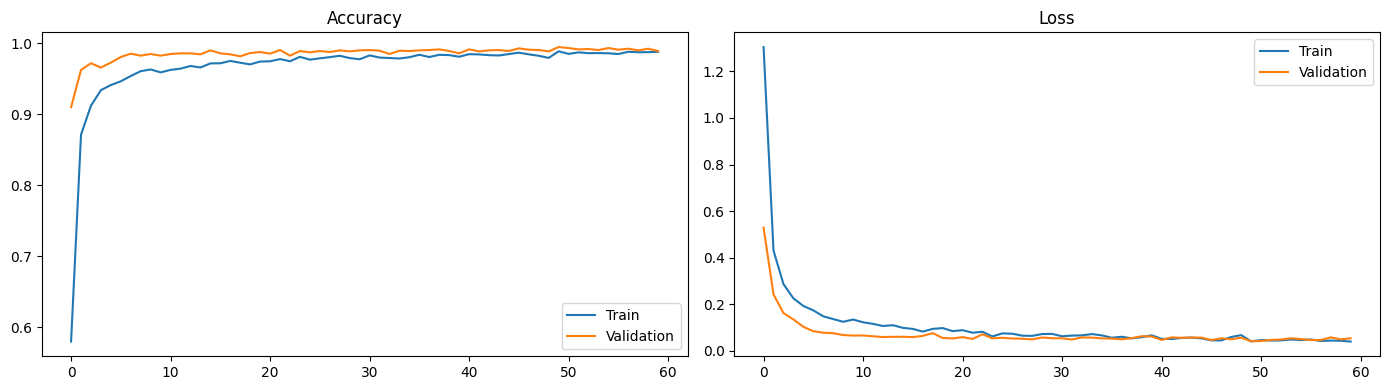

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy'); ax1.legend()

ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Loss'); ax2.legend()

plt.tight_layout(); plt.show()

113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Test Accuracy: 98.77%
                  precision    recall  f1-score   support

Acetaldehyde_500       0.99      1.00      1.00       336
    Acetone_2500       0.99      1.00      0.99       335
   Ammonia_10000       0.99      1.00      0.99       336
     Benzene_200       0.99      1.00      1.00       336
     Butanol_100       0.97      0.98      0.98       275
         CO_1000       0.97      1.00      0.98        65
         CO_4000       1.00      0.99      0.99       290
    Ethylene_500       0.99      0.98      0.99       336
    Methane_1000       0.99      1.00      1.00       336
    Methanol_200       0.97      0.99      0.98       336
    Sensor_Fault       0.99      0.91      0.95       268
     Toluene_200       0.98      1.00      0.99       336

        accuracy                           0.99      3585
       macro avg       0.99      0.99      0.99      3585
    weighted avg       0.99      0.99      0.99      3585



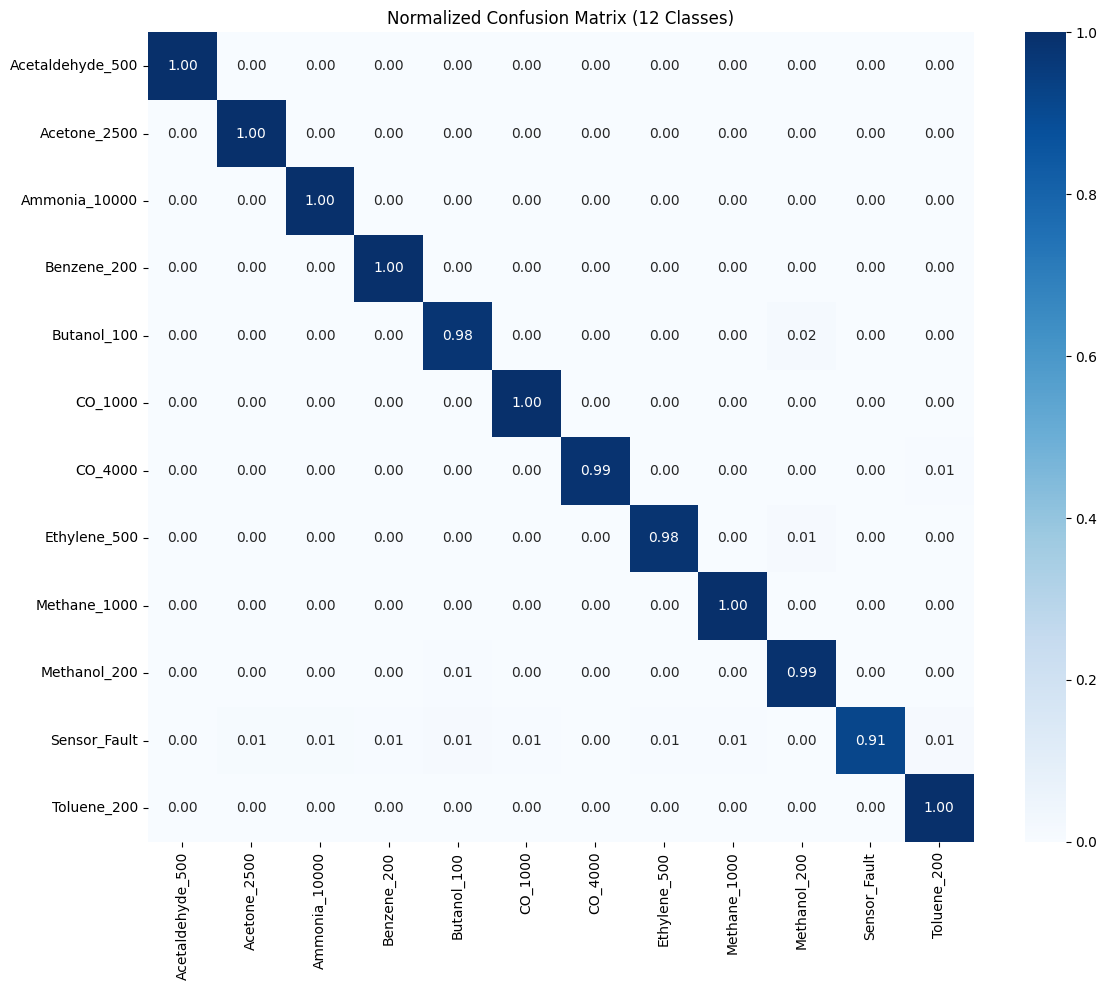

In [11]:
y_pred_probs = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)

test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, normalize='true')
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='.2f',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cmap='Blues')
plt.title('Normalized Confusion Matrix (12 Classes)')
plt.tight_layout(); plt.show()

In [12]:
# Save full Keras model first
model.save('gas_classifier_full.h5')

# Representative dataset — randomized to cover all classes including CO_1000
def representative_dataset():
    indices = np.random.choice(len(X_train_scaled), size=200, replace=False)
    for i in indices:
        sample = X_train_scaled[i:i+1].astype(np.float32)
        yield [sample]

# Convert to int8
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type  = tf.int8
converter.inference_output_type = tf.int8

tflite_model = converter.convert()

with open('gas_classifier_int8.tflite', 'wb') as f:
    f.write(tflite_model)

print(f"TFLite model size: {len(tflite_model) / 1024:.1f} KB")

# Verify the TFLite model gives same predictions as Keras model
interpreter_tflite = tf.lite.Interpreter(model_content=tflite_model)
interpreter_tflite.allocate_tensors()

input_details  = interpreter_tflite.get_input_details()
output_details = interpreter_tflite.get_output_details()

# Test on first 10 samples from test set
print("\nKeras vs TFLite prediction check:")
for i in range(10):
    # Keras prediction
    keras_pred = np.argmax(model.predict(X_test_scaled[i:i+1], verbose=0))
    
    # TFLite prediction (needs int8 quantization)
    scale     = input_details[0]['quantization'][0]
    zero_pt   = input_details[0]['quantization'][1]
    quantized = (X_test_scaled[i:i+1] / scale + zero_pt).astype(np.int8)
    
    interpreter_tflite.set_tensor(input_details[0]['index'], quantized)
    interpreter_tflite.invoke()
    tflite_pred = np.argmax(interpreter_tflite.get_tensor(output_details[0]['index']))
    
    match = "✓" if keras_pred == tflite_pred else "✗ MISMATCH"
    print(f"  Sample {i}: Keras={label_encoder.classes_[keras_pred]:<20} "
          f"TFLite={label_encoder.classes_[tflite_pred]:<20} {match}")

INFO:tensorflow:Assets written to: C:\Users\svchi\AppData\Local\Temp\tmp8nzdwfxd\assets


INFO:tensorflow:Assets written to: C:\Users\svchi\AppData\Local\Temp\tmp8nzdwfxd\assets


Saved artifact at 'C:\Users\svchi\AppData\Local\Temp\tmp8nzdwfxd'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 288), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 12), dtype=tf.float32, name=None)
Captures:
  2335694614992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2335694615760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2335694616912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2335694617296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2335694614416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2335694615952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2335694616336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2335694617680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2335694618064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2335694618256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  233569461710

D:\Sivaram\VIT files\Sem 6\EMBEDDED\Final Project\venv\Lib\site-packages\tensorflow\lite\python\convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


TFLite model size: 27.6 KB

Keras vs TFLite prediction check:
  Sample 0: Keras=Methane_1000         TFLite=Methane_1000         ✓
  Sample 1: Keras=Acetone_2500         TFLite=Acetone_2500         ✓
  Sample 2: Keras=Butanol_100          TFLite=Butanol_100          ✓


D:\Sivaram\VIT files\Sem 6\EMBEDDED\Final Project\venv\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


  Sample 3: Keras=Methanol_200         TFLite=Methanol_200         ✓
  Sample 4: Keras=Benzene_200          TFLite=Benzene_200          ✓
  Sample 5: Keras=Methanol_200         TFLite=Methanol_200         ✓
  Sample 6: Keras=CO_4000              TFLite=CO_4000              ✓
  Sample 7: Keras=Benzene_200          TFLite=Benzene_200          ✓
  Sample 8: Keras=Sensor_Fault         TFLite=Toluene_200          ✗ MISMATCH
  Sample 9: Keras=Butanol_100          TFLite=Butanol_100          ✓


In [13]:
# %%
# Step 10 — Generate the C Header File (gas_model.h)

import binascii

with open('gas_classifier_int8.tflite', 'rb') as f:
    tflite_bytes = f.read()

# Convert to C array
c_array_lines = []
for i in range(0, len(tflite_bytes), 12):
    chunk = tflite_bytes[i:i+12]
    c_array_lines.append('  ' + ', '.join(f'0x{b:02x}' for b in chunk))

# FIX: Join with a comma AND a newline
c_array_block = ',\n'.join(c_array_lines)

c_header = f"""// gas_model.h — Auto-generated from gas_classifier_int8.tflite
// Model size: {len(tflite_bytes)} bytes ({len(tflite_bytes)/1024:.1f} KB)
// DO NOT EDIT MANUALLY

#ifndef GAS_MODEL_H
#define GAS_MODEL_H

#include <pgmspace.h>

const unsigned int gas_model_len = {len(tflite_bytes)};

// alignas(8) is required by TensorFlow Lite for Microcontrollers
// static prevents multiple definition errors
alignas(8) static const unsigned char gas_model_data[] PROGMEM = {{
{c_array_block}
}};

#endif // GAS_MODEL_H
"""

with open('gas_model.h', 'w') as f:
    f.write(c_header)

print(f"gas_model.h written — {len(tflite_bytes)} bytes ({len(tflite_bytes)/1024:.1f} KB)")
print(f"Array lines: {len(c_array_lines)}")

gas_model.h written — 28272 bytes (27.6 KB)
Array lines: 2356


In [14]:
# %%
# Step 11 — Export Scaler Parameters as C header (scaler_params.h)

means  = scaler.mean_
scales = scaler.scale_
n_features = len(means)

def fmt_float_array(name, values):
    vals = ',\n  '.join(f'{v:.8f}f' for v in values)
    # FIX: Added 'static'
    return f"static const float {name}[{len(values)}] = {{\n  {vals}\n}};"

scaler_header = f"""// scaler_params.h — Auto-generated StandardScaler parameters
// Features: {n_features}
// Usage on ESP32:
//   input_scaled[i] = (raw[i] - SCALER_MEAN[i]) / SCALER_STD[i];

#ifndef SCALER_PARAMS_H
#define SCALER_PARAMS_H

#define N_FEATURES {n_features}

{fmt_float_array("SCALER_MEAN", means)}

{fmt_float_array("SCALER_STD", scales)}

#endif // SCALER_PARAMS_H
"""

with open('scaler_params.h', 'w') as f:
    f.write(scaler_header)

print(f"scaler_params.h written — {n_features} features")
print(f"Mean range:  [{means.min():.4f}, {means.max():.4f}]")
print(f"Scale range: [{scales.min():.4f}, {scales.max():.4f}]")

# %%
# Also export label mapping as a C header (labels.h)

label_header = f"""// labels.h — Auto-generated class label mapping
// {num_classes} classes

#ifndef LABELS_H
#define LABELS_H

#define N_CLASSES {num_classes}

// FIX: Added 'static'
static const char* CLASS_LABELS[{num_classes}] = {{
  {', '.join(f'"{cls}"' for cls in label_encoder.classes_)}
}};

#endif // LABELS_H
"""

with open('labels.h', 'w') as f:
    f.write(label_header)

print("\nlabels.h written:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"  {i} → {cls}")

scaler_params.h written — 288 features
Mean range:  [0.0016, 0.5733]
Scale range: [0.0239, 0.3179]

labels.h written:
  0 → Acetaldehyde_500
  1 → Acetone_2500
  2 → Ammonia_10000
  3 → Benzene_200
  4 → Butanol_100
  5 → CO_1000
  6 → CO_4000
  7 → Ethylene_500
  8 → Methane_1000
  9 → Methanol_200
  10 → Sensor_Fault
  11 → Toluene_200


In [15]:
# %%
# Step 12 — ThingSpeak Integration

import requests
import time

THINGSPEAK_WRITE_API_KEY = "SHE39S6B1CV71J88"   # <-- replace
THINGSPEAK_CHANNEL_ID    = "3330882"       # <-- replace
THINGSPEAK_URL           = "https://api.thingspeak.com/update"

# %%
# Helper function to build payload
def build_thingspeak_payload(pred_class_idx, pred_probs, label_encoder):
    sorted_idx   = np.argsort(pred_probs)[::-1]
    top_label    = label_encoder.classes_[sorted_idx[0]]
    top_conf     = pred_probs[sorted_idx[0]]
    runner_idx   = sorted_idx[1]
    runner_conf  = pred_probs[runner_idx]
    is_fault     = 1 if top_label == 'Sensor_Fault' else 0

    payload = {
        'api_key': THINGSPEAK_WRITE_API_KEY,
        'field1':  int(pred_class_idx),         # predicted class index
        'field2':  float(round(top_conf, 4)),   # confidence
        'field3':  is_fault,                    # sensor fault flag
        'field4':  float(round(runner_conf, 4)),# runner-up confidence
        'field5':  int(runner_idx),             # runner-up class index
    }
    return payload, top_label, top_conf

# %%
# DRY RUN — no HTTP call, just verify payload structure
print("=" * 55)
print("DRY RUN — No data sent to ThingSpeak")
print("=" * 55)

for i in range(5):
    probs    = y_pred_probs[i]
    pred_idx = np.argmax(probs)
    payload, label, conf = build_thingspeak_payload(pred_idx, probs, label_encoder)
    true_label = label_encoder.classes_[y_test[i]]

    print(f"\nSample {i}:")
    print(f"  True label      : {true_label}")
    print(f"  Predicted       : {label} ({conf*100:.1f}%)")
    print(f"  Sensor fault    : {'YES' if payload['field3'] else 'NO'}")
    print(f"  Payload         : {payload}")

# %%
# LIVE POST — sends real data to ThingSpeak
# ThingSpeak free tier limit: 1 update per 15 seconds
print("\n" + "=" * 55)
print("LIVE POST — Sending 5 samples to ThingSpeak")
print("=" * 55)

for i in range(5):
    probs    = y_pred_probs[i]
    pred_idx = np.argmax(probs)
    payload, label, conf = build_thingspeak_payload(pred_idx, probs, label_encoder)
    true_label = label_encoder.classes_[y_test[i]]

    try:
        resp = requests.post(THINGSPEAK_URL, data=payload, timeout=10)

        if resp.status_code == 200 and resp.text != '0':
            print(f"\nSample {i} → SENT ✓")
            print(f"  Predicted : {label} ({conf*100:.1f}%)")
            print(f"  True      : {true_label}")
            print(f"  Entry ID  : {resp.text.strip()}")
        else:
            print(f"\nSample {i} → FAILED ✗")
            print(f"  Status code : {resp.status_code}")
            print(f"  Response    : {resp.text.strip()}")
            print(f"  Check your API key and Channel ID")

    except requests.exceptions.Timeout:
        print(f"\nSample {i} → TIMEOUT ✗ (ThingSpeak didn't respond in 10s)")
    except requests.exceptions.ConnectionError:
        print(f"\nSample {i} → CONNECTION ERROR ✗ (check your internet)")

    if i < 4:  # no need to wait after the last one
        print(f"  Waiting 16s before next post...")
        time.sleep(16)

print("\n" + "=" * 55)
print("Done — check your ThingSpeak channel for the entries")
print(f"https://thingspeak.com/channels/{THINGSPEAK_CHANNEL_ID}")
print("=" * 55)

DRY RUN — No data sent to ThingSpeak

Sample 0:
  True label      : Methane_1000
  Predicted       : Methane_1000 (100.0%)
  Sensor fault    : NO
  Payload         : {'api_key': 'SHE39S6B1CV71J88', 'field1': 8, 'field2': 0.9998000264167786, 'field3': 0, 'field4': 0.00019999999494757503, 'field5': 10}

Sample 1:
  True label      : Acetone_2500
  Predicted       : Acetone_2500 (100.0%)
  Sensor fault    : NO
  Payload         : {'api_key': 'SHE39S6B1CV71J88', 'field1': 1, 'field2': 1.0, 'field3': 0, 'field4': 0.0, 'field5': 10}

Sample 2:
  True label      : Butanol_100
  Predicted       : Butanol_100 (100.0%)
  Sensor fault    : NO
  Payload         : {'api_key': 'SHE39S6B1CV71J88', 'field1': 4, 'field2': 0.9997000098228455, 'field3': 0, 'field4': 9.999999747378752e-05, 'field5': 10}

Sample 3:
  True label      : Methanol_200
  Predicted       : Methanol_200 (99.8%)
  Sensor fault    : NO
  Payload         : {'api_key': 'SHE39S6B1CV71J88', 'field1': 9, 'field2': 0.9976999759674072, 'f

In [16]:
# %%
# Step 13 — Export pre-scaled test vectors for Wokwi simulation
# with forced Sensor_Fault representation

from collections import defaultdict, Counter

N_WOKWI_SAMPLES      = 20
N_FORCED_FAULT       = 5   # <-- adjust how many fault samples you want

# Stratified selection — at least 1 sample per class
samples_per_class = defaultdict(list)
for i in range(len(X_test_scaled)):
    cls = y_test[i]
    samples_per_class[cls].append(i)

rng_wokwi = np.random.default_rng(0)

# Force N_FORCED_FAULT Sensor_Fault samples first
fault_class_idx = list(label_encoder.classes_).index('Sensor_Fault')
fault_pool      = samples_per_class[fault_class_idx]
forced_faults   = list(rng_wokwi.choice(fault_pool, size=N_FORCED_FAULT, replace=False))

# Then 1 per remaining class (excluding Sensor_Fault)
selected_indices = forced_faults.copy()
for cls_idx in sorted(samples_per_class.keys()):
    if cls_idx == fault_class_idx:
        continue
    pool = samples_per_class[cls_idx]
    pick = rng_wokwi.choice(pool)
    selected_indices.append(pick)

# Pad to N_WOKWI_SAMPLES if still short
remaining = list(set(range(len(X_test_scaled))) - set(selected_indices))
rng_wokwi.shuffle(remaining)
selected_indices += remaining[:max(0, N_WOKWI_SAMPLES - len(selected_indices))]
selected_indices  = selected_indices[:N_WOKWI_SAMPLES]
# Shuffle so fault samples are not bunched together
rng_wokwi.shuffle(selected_indices)

# Build the vectors and true labels
wokwi_vectors = X_test_scaled[selected_indices].astype(np.float32)
wokwi_labels  = [label_encoder.classes_[y_test[i]] for i in selected_indices]



# Build C array block
lines = []
for row_i, (vec, lbl) in enumerate(zip(wokwi_vectors, wokwi_labels)):
    vals = ', '.join(f'{v:.6f}f' for v in vec)
    # FIX: Add a comma if it's NOT the last row
    comma = "," if row_i < len(wokwi_vectors) - 1 else ""
    lines.append(f"  {{ {vals} }}{comma}  // [{row_i}] true={lbl}")

wokwi_array_block = '\n'.join(lines)
n_features = X_test_scaled.shape[1]

wokwi_header = f"""// wokwi_test_vectors.h — {N_WOKWI_SAMPLES} pre-scaled test vectors for Wokwi simulation
// Shape: [{N_WOKWI_SAMPLES}][{n_features}]
// These are already StandardScaler-transformed — do NOT scale again on ESP32

#ifndef WOKWI_TEST_VECTORS_H
#define WOKWI_TEST_VECTORS_H

#include <pgmspace.h>

#define N_TEST_VECTORS {N_WOKWI_SAMPLES}
#define N_FEATURES     {n_features}

// FIX: Added 'static'
static const char* TRUE_LABELS[{N_WOKWI_SAMPLES}] = {{
  {', '.join(f'"{l}"' for l in wokwi_labels)}
}};

// FIX: Added 'static' and 'PROGMEM'
static const float TEST_VECTORS[{N_WOKWI_SAMPLES}][{n_features}] PROGMEM = {{
{wokwi_array_block}
}};

#endif // WOKWI_TEST_VECTORS_H
"""

with open('wokwi_test_vectors.h', 'w') as f:
    f.write(wokwi_header)

print(f"wokwi_test_vectors.h written")
print(f"  {N_WOKWI_SAMPLES} vectors x {n_features} features")
print(f"\nClass coverage in exported vectors:")
print(Counter(wokwi_labels))

wokwi_test_vectors.h written
  20 vectors x 288 features

Class coverage in exported vectors:
Counter({'Sensor_Fault': 5, 'Methanol_200': 3, 'CO_4000': 2, 'Ethylene_500': 2, 'Acetone_2500': 1, 'Ammonia_10000': 1, 'Methane_1000': 1, 'Benzene_200': 1, 'Toluene_200': 1, 'Butanol_100': 1, 'CO_1000': 1, 'Acetaldehyde_500': 1})


In [16]:
fault_idx = list(label_encoder.classes_).index('Sensor_Fault')
print(f"Sensor_Fault index: {fault_idx}")

Sensor_Fault index: 10


In [17]:
df_fault['Chemical'].value_counts().sort_values()
df_fault.to_csv('chemicals_in_wind_tunnel_fault.csv')